# SVM Analytics Drill-Down

This notebook auto-loads the latest analytics run from `output/analytics/` and provides interactive drill-down views for:

- threshold tradeoffs
- review-volume behavior
- top feature weights
- PCA projection
- generated PNG charts

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'output').exists():
    BASE_DIR = BASE_DIR.parent

ANALYTICS_ROOT = BASE_DIR / 'output' / 'analytics'
if not ANALYTICS_ROOT.exists():
    raise FileNotFoundError(f'Analytics folder not found: {ANALYTICS_ROOT}')

run_dirs = [d for d in ANALYTICS_ROOT.iterdir() if d.is_dir() and d.name.startswith('svm_analytics_')]
if not run_dirs:
    raise FileNotFoundError('No analytics run folders found under output/analytics. Run: python scripts/svm_analytics.py')

latest_run = max(run_dirs, key=lambda p: p.stat().st_mtime)
print(f'Latest analytics run: {latest_run}')

Latest analytics run: /home/jacobmiller/EnvisionPerdido/output/analytics/svm_analytics_20260317_074123


In [2]:
threshold_csv = latest_run / 'threshold_sweep.csv'
features_csv = latest_run / 'top_features.csv'
pca_csv = latest_run / 'pca_projection.csv'

threshold_df = pd.read_csv(threshold_csv)
features_df = pd.read_csv(features_csv)
pca_df = pd.read_csv(pca_csv) if pca_csv.exists() else pd.DataFrame()

print('Threshold sweep rows:', len(threshold_df))
print('Top features rows:', len(features_df))
print('PCA rows:', len(pca_df))

display(threshold_df.head(10))
display(features_df.head(20))
display(pca_df.head(20) if not pca_df.empty else pca_df)

Threshold sweep rows: 240
Top features rows: 20
PCA rows: 374


,threshold,accuracy,precision_1,recall_1,f1_1,review_rate
0,-0.985596,0.537433,0.537433,1.000000,0.699130,0.927807
1,-0.972588,0.542781,0.540323,1.000000,0.701571,0.927807
2,-0.969653,0.545455,0.541779,1.000000,0.702797,0.927807
3,-0.965850,0.548128,0.543243,1.000000,0.704028,0.927807
4,-0.964654,0.550802,0.544715,1.000000,0.705263,0.927807
5,-0.961298,0.548128,0.543478,0.995025,0.702988,0.927807
6,-0.952221,0.550802,0.544959,0.995025,0.704225,0.927807
7,-0.940212,0.553476,0.546448,0.995025,0.705467,0.927807
8,-0.939842,0.556150,0.547945,0.995025,0.706714,0.927807
9,-0.938477,0.558824,0.549451,0.995025,0.707965,0.927807


,feature,weight,direction
0,is_weekend,0.489515,community
1,hour,-0.437797,non_community
2,club,-0.349821,non_community
3,business,-0.346193,non_community
4,meeting,-0.322399,non_community
5,wine,0.305127,community
6,room,0.273767,community
7,limited,0.253004,community
8,speaker,-0.250535,non_community
9,community,-0.248171,non_community


,pc1,pc2,true_label,pred_label,correct
0,-0.428337,-0.556022,1,1,1
1,-0.064173,-0.185144,0,0,1
2,-0.421106,-0.561966,1,1,1
3,0.049926,-0.050842,0,1,0
4,-0.425187,-0.557336,1,1,1
5,-0.428337,-0.556022,1,1,1
6,0.081544,-0.036782,0,0,1
7,-0.421106,-0.561966,1,1,1
8,0.339841,-0.278003,0,1,0
9,-0.425187,-0.557336,1,1,1


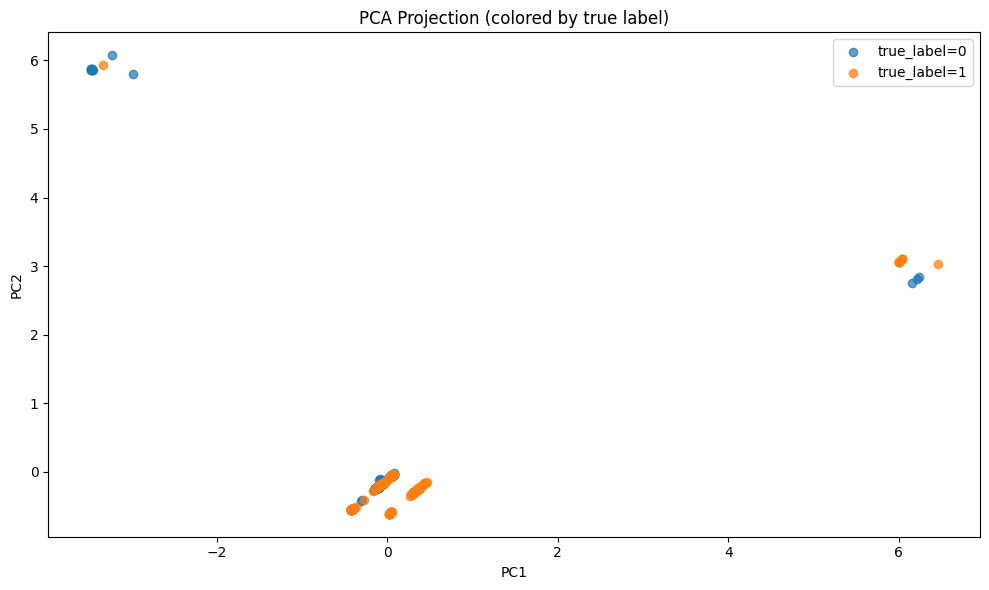

In [3]:
# PCA drill-down scatter (if PCA output is present)
if pca_df.empty:
    print('No PCA projection data found in latest run.')
else:
    plt.figure(figsize=(10, 6))
    for label in sorted(pca_df['true_label'].unique()):
        subset = pca_df[pca_df['true_label'] == label]
        plt.scatter(subset['pc1'], subset['pc2'], label=f'true_label={label}', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Projection (colored by true label)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
# Drill-down: choose a threshold and inspect expected behavior
selected_threshold = float(threshold_df.loc[threshold_df['f1_1'].idxmax(), 'threshold'])
nearest_idx = (threshold_df['threshold'] - selected_threshold).abs().idxmin()
row = threshold_df.loc[nearest_idx]

print(f'Selected threshold: {row["threshold"]:.4f}')
print(f'Accuracy: {row["accuracy"]:.4f}')
print(f'Class-1 Precision: {row["precision_1"]:.4f}')
print(f'Class-1 Recall: {row["recall_1"]:.4f}')
print(f'Class-1 F1: {row["f1_1"]:.4f}')
print(f'Estimated review rate: {row["review_rate"]:.2%}')

Selected threshold: -0.4959
Accuracy: 0.8636
Class-1 Precision: 0.8348
Class-1 Recall: 0.9303
Class-1 F1: 0.8800
Estimated review rate: 92.78%


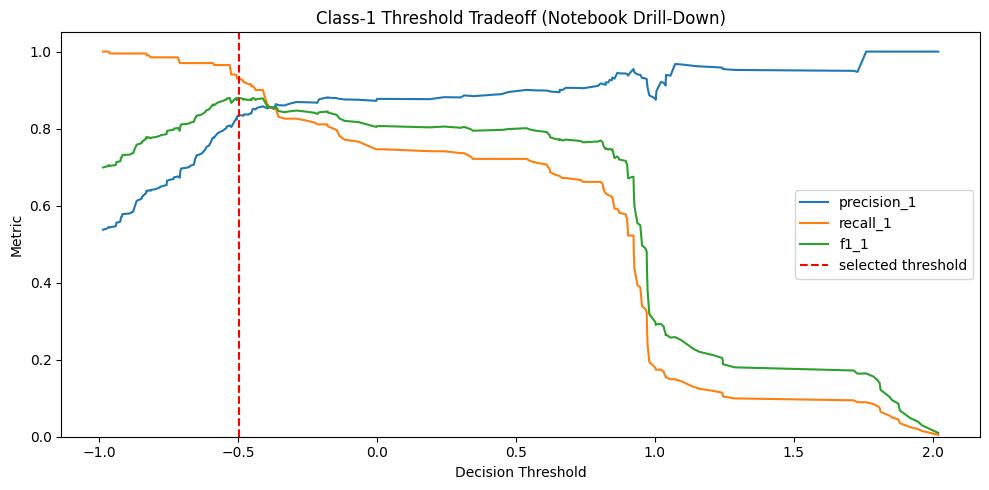

In [5]:
# Plot threshold tradeoff interactively in notebook
plt.figure(figsize=(10, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision_1'], label='precision_1')
plt.plot(threshold_df['threshold'], threshold_df['recall_1'], label='recall_1')
plt.plot(threshold_df['threshold'], threshold_df['f1_1'], label='f1_1')
plt.axvline(selected_threshold, color='red', linestyle='--', label='selected threshold')
plt.ylim(0, 1.05)
plt.xlabel('Decision Threshold')
plt.ylabel('Metric')
plt.title('Class-1 Threshold Tradeoff (Notebook Drill-Down)')
plt.legend()
plt.tight_layout()
plt.show()

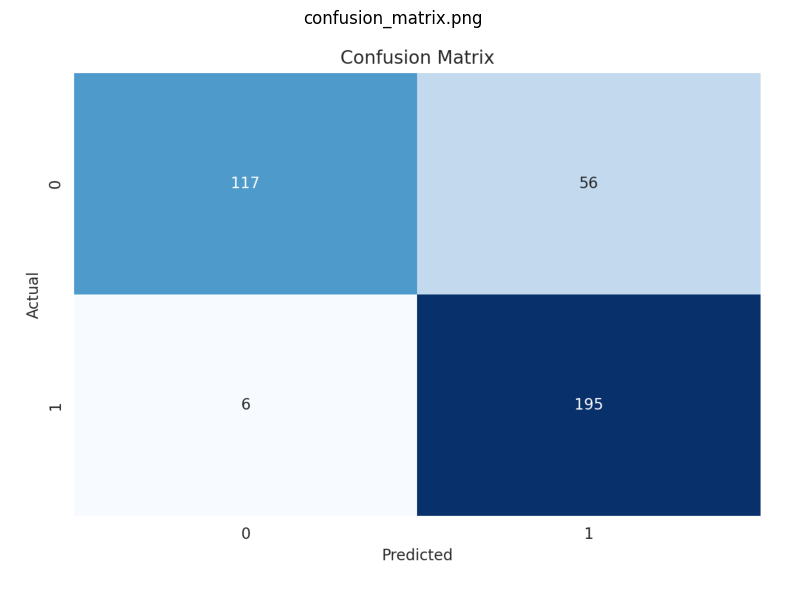

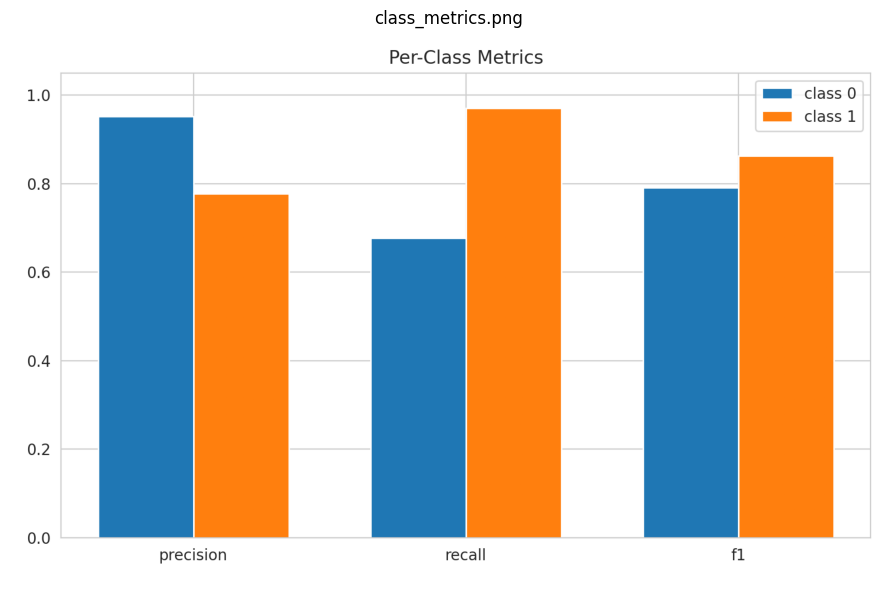

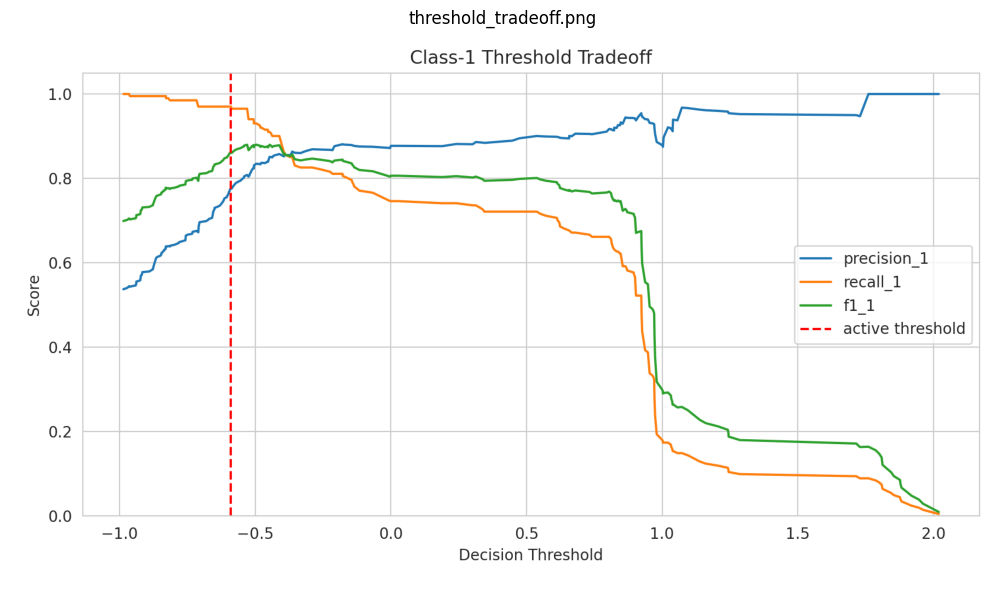

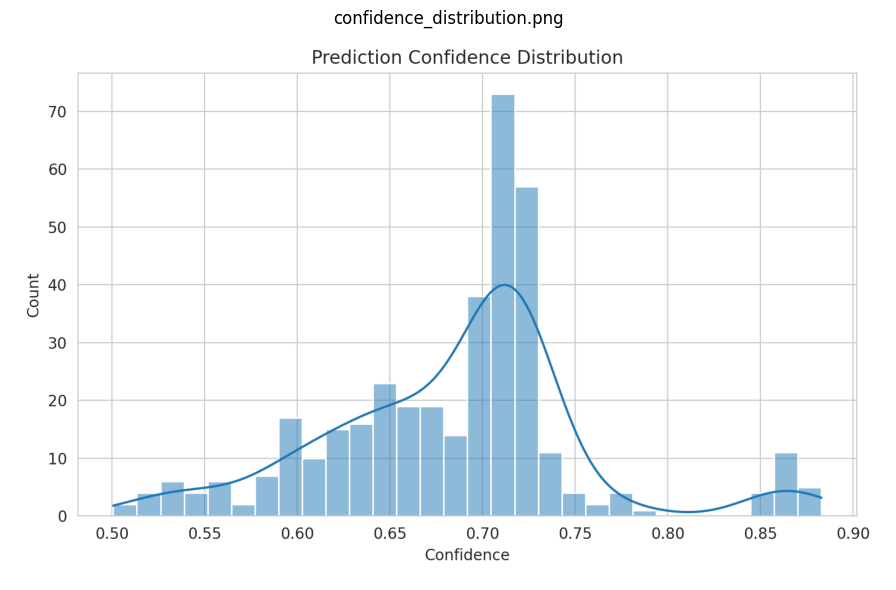

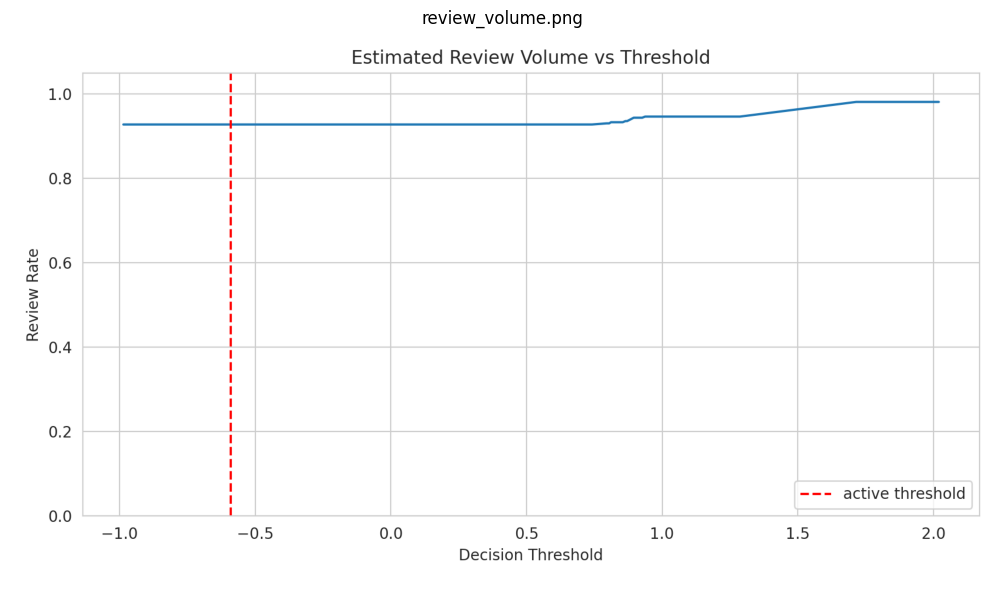

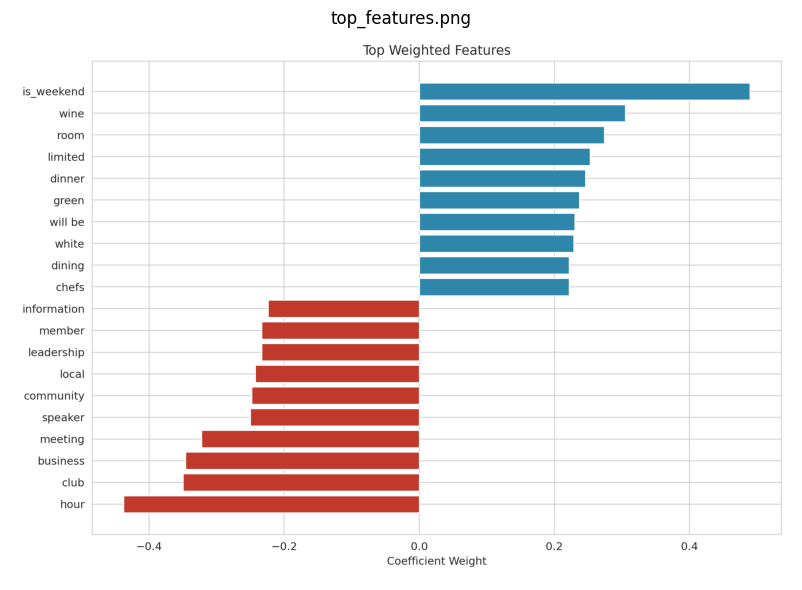

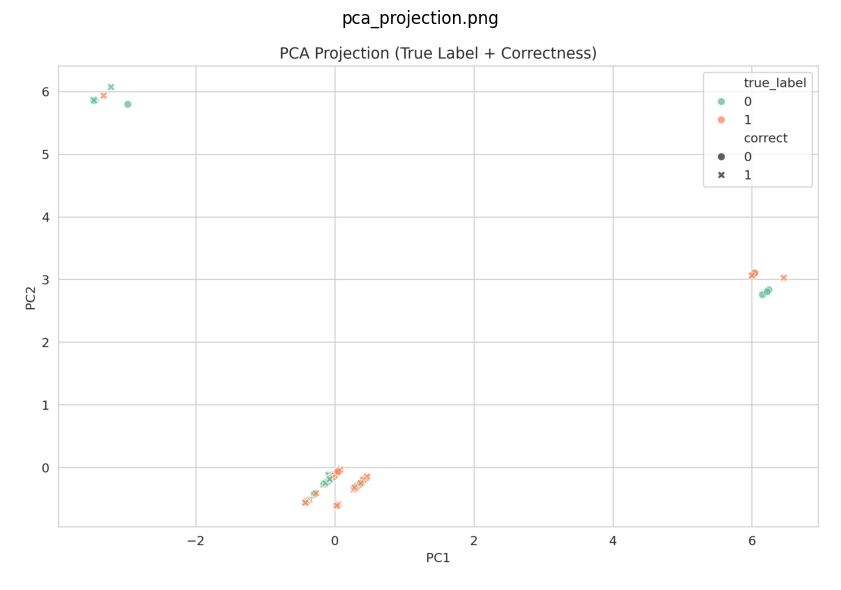

In [6]:
# Show generated analytics images from latest run
image_files = [
    'confusion_matrix.png',
    'class_metrics.png',
    'threshold_tradeoff.png',
    'confidence_distribution.png',
    'review_volume.png',
    'top_features.png',
    'pca_projection.png',
]

for img_name in image_files:
    img_path = latest_run / img_name
    if not img_path.exists():
        print(f'Missing image: {img_path}')
        continue

    img = mpimg.imread(img_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.tight_layout()
    plt.show()